In [7]:
# from PIL import Image, ImageDraw, ImageFont
# file_name = "1655934992718_default_1280-720"

# # /home/kopsahlong/eclair-agents/eclair/webpage_segmentation/eval/label_to_bb/OpenAI_Segmentation/labels/yolo_nas_l_webui_Conf_0.3_gt_True/images/1656378101975_default_1280-720.jpg
# # /media/nvme_data/ehr_workflows/hf_home/hub/webui-7k-yolo-inner-box/test/images/1655947618054_default_1920-1080.jpg
# # /media/nvme_data/ehr_workflows/hf_home/hub/webui-7k-yolo-inner-box/

# # /media/nvme_data/ehr_workflows/hf_home/hub/webui-7k-yolo-inner-box-7/valid/images/1655885015127_default_1366-768.jpg
# images_dir = "/media/nvme_data/ehr_workflows/hf_home/hub/webui-7k-yolo-inner-box-10/test/images"
# labels_dir = "/media/nvme_data/ehr_workflows/hf_home/hub/webui-7k-yolo-inner-box-10/test/labels"
# # /media/nvme_data/ehr_workflows/hf_home/hub/webui-7k-yolo-inner-box/train/labels/1655885631145_default_1920-1080.txt

# image_path = f"{images_dir}/{file_name}.jpg"
# bb_data_path = f"{labels_dir}/{file_name}.txt"

# def clean_and_filter_boxes(bounding_boxes):
#     # Remove None entries
#     cleaned_boxes = {k: v for k, v in bounding_boxes.items() if v is not None and v['width'] > 0 and v['height'] > 0}

#     # Reuse the previous function to filter the cleaned boxes
#     return cleaned_boxes

# with open(bb_data_path, 'r') as file:
#     bb_data = file.readlines()

In [8]:
import pandas as pd
import pickle

df = pd.read_csv("/home/kopsahlong/eclair-agents/eclair/webpage_segmentation/datasets/bounding-box-labels/bb_labels_cropped.csv")

row = df.iloc[0]
image_path = row["image_path"]
label_path = row["image_path"].replace("cropped_images","cropped_bbs").replace(".jpg",".pickle")

with open(label_path, 'rb') as file:
    bounding_boxes = pickle.load(file)

In [9]:
# To load and visualize a .webp image in a Python notebook, we'll use the Pillow library.
from PIL import Image
import io
import IPython.display as display
from PIL import Image, ImageDraw, ImageFont

# First, we'll load the image using Pillow
# image_path = f'{example_path}/default_1280-720-screenshot-full.webp'
image = Image.open(image_path)

# Now, let's display the image directly in the notebook.

# Initialize the drawing context with your image as background
draw = ImageDraw.Draw(image)

# Image dimensions
img_width, img_height = image.size

# Iterate over bounding box data and draw each box
for box in bounding_boxes:  # Use json_data directly
    
    # Scale coordinates and dimensions to fit the image size
    # x_center_scaled = box['x'] * img_width
    # y_center_scaled = box['y'] * img_height
    # width_scaled = box['width'] * img_width
    # height_scaled = box['height'] * img_height

    x_center_scaled = box[0] * img_width
    y_center_scaled = box[1] * img_height
    width_scaled = box[2] * img_width
    height_scaled = box[3] * img_height

    # Calculate top-left and bottom-right coordinates
    top_left = (x_center_scaled - width_scaled / 2, y_center_scaled - height_scaled / 2)
    bottom_right = (x_center_scaled + width_scaled / 2, y_center_scaled + height_scaled / 2)

    # Draw the rectangle
    draw.rectangle([top_left, bottom_right], outline="red")

    # Draw a green dot at the center
    center = (x_center_scaled, y_center_scaled)
    draw.ellipse([center[0]-2, center[1]-2, center[0]+2, center[1]+2], fill="green")

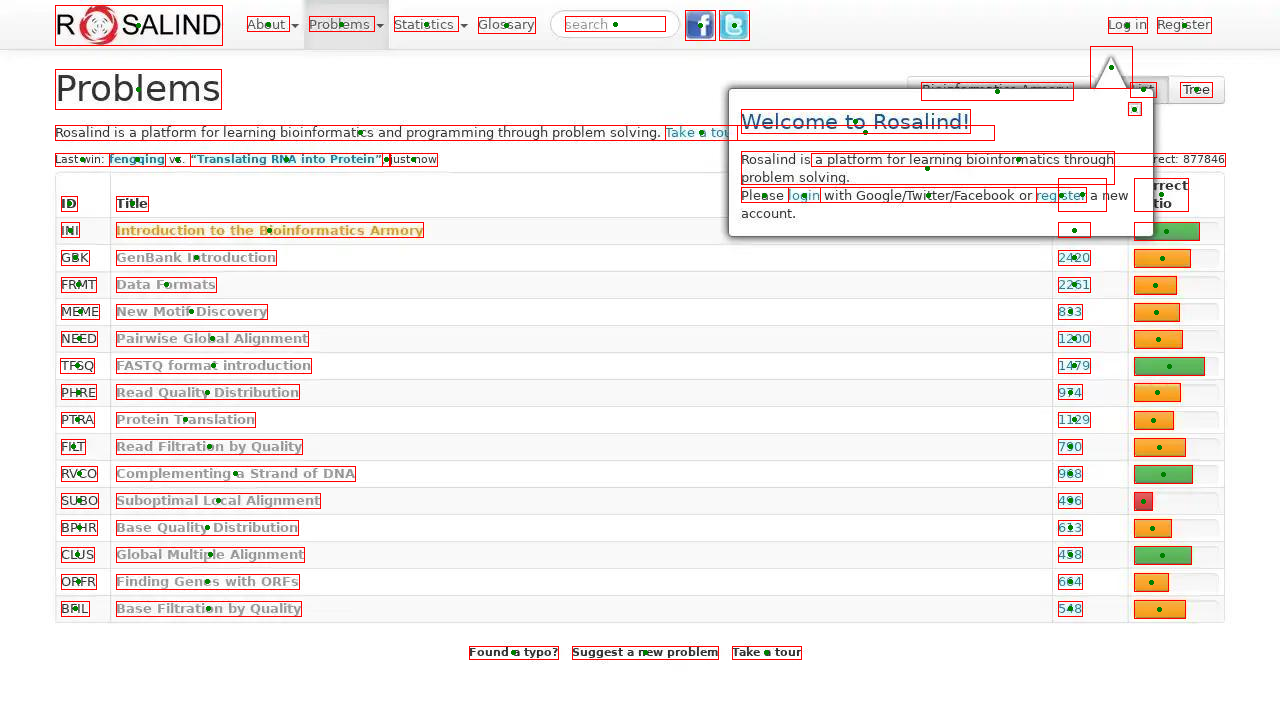

In [10]:
from IPython.display import display

display(image)